Epoch 0 | Train Loss: 0.030012 | Val Loss: 0.030002
Epoch 20 | Train Loss: 0.009064 | Val Loss: 0.008580
Epoch 40 | Train Loss: 0.007141 | Val Loss: 0.008854
Epoch 60 | Train Loss: 0.006016 | Val Loss: 0.005870
Epoch 80 | Train Loss: 0.005824 | Val Loss: 0.005591
Epoch 100 | Train Loss: 0.004970 | Val Loss: 0.005125
Epoch 120 | Train Loss: 0.004932 | Val Loss: 0.005528
Epoch 140 | Train Loss: 0.004883 | Val Loss: 0.005244
Epoch 160 | Train Loss: 0.004425 | Val Loss: 0.005141
Epoch 180 | Train Loss: 0.003949 | Val Loss: 0.004260

Best model at epoch 199 with val loss 0.003901


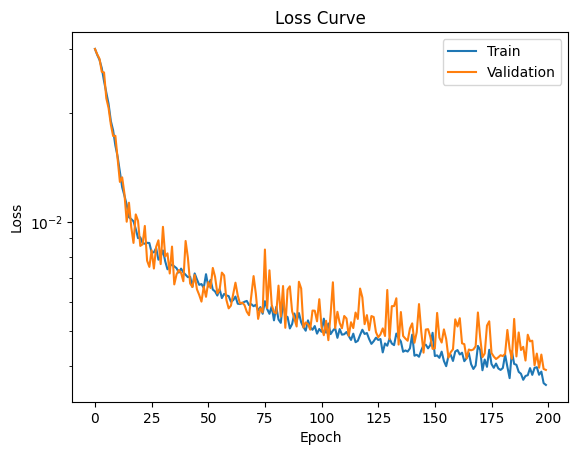

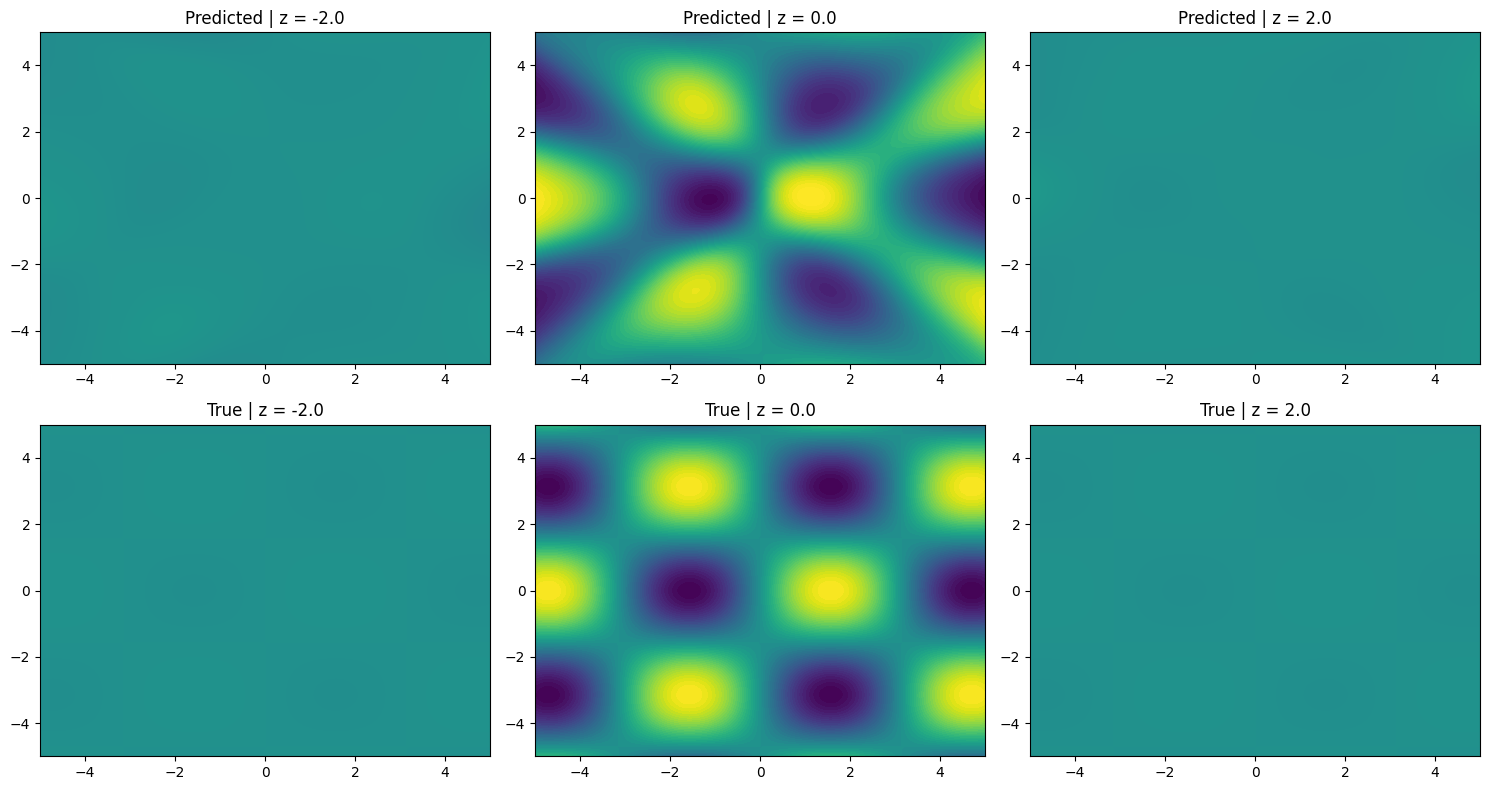

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Data generation
x = torch.linspace(-5, 5, 20)
y = torch.linspace(-5, 5, 20)
z = torch.linspace(-5, 5, 20)
X, Y, Z = torch.meshgrid(x, y, z, indexing='ij')

v = torch.flatten(torch.sin(X) * torch.cos(Y) * torch.exp(-Z**2)).view(-1, 1)
xyz = torch.stack([X.flatten(), Y.flatten(), Z.flatten()], dim=1)

# Shuffle and split
indices = torch.randperm(xyz.shape[0])
xyz = xyz[indices]
v = v[indices]

split = int(0.8 * len(xyz))
xyz_train, xyz_val = xyz[:split], xyz[split:]
v_train, v_val = v[:split], v[split:]

# DataLoader
dataset = TensorDataset(xyz_train, v_train)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Model
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.input = nn.Linear(3, 32)
        self.l1 = nn.Linear(32, 32)
        self.l2 = nn.Linear(32, 32)
        self.l3 = nn.Linear(32, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, xyz):
        xyz = torch.tanh(self.input(xyz))
        xyz = torch.tanh(self.l1(xyz))
        xyz = torch.tanh(self.l2(xyz))
        xyz = torch.tanh(self.l3(xyz))
        return self.output(xyz)

model = Net()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.MSELoss()

# Training loop
train_losses = []
val_losses = []

best_val_loss = float('inf')
best_epoch = 0

for epoch in range(200):
    model.train()
    epoch_loss = 0

    for batch_xyz, batch_v in dataloader:
        optimizer.zero_grad()
        pred = model(batch_xyz)
        loss = criterion(batch_v, pred)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(dataloader)
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        val_pred = model(xyz_val)
        val_loss = criterion(v_val, val_pred).item()
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_model.pt')

    if epoch % 20 == 0:
        print(f'Epoch {epoch} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}')

# Load best model
model.load_state_dict(torch.load('best_model.pt'))
print(f'\nBest model at epoch {best_epoch} with val loss {best_val_loss:.6f}')

# Loss curve
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

# Slice plot
x_plot = torch.linspace(-5, 5, 100)
y_plot = torch.linspace(-5, 5, 100)
X_plot, Y_plot = torch.meshgrid(x_plot, y_plot, indexing='ij')
z_values = [-2.0, 0.0, 2.0]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, z_val in enumerate(z_values):
    Z_plot = torch.full_like(X_plot, z_val)
    inputs = torch.stack([X_plot.flatten(), Y_plot.flatten(), Z_plot.flatten()], dim=1)

    model.eval()
    with torch.no_grad():
        preds = model(inputs).reshape(100, 100)

    true = torch.sin(X_plot) * torch.cos(Y_plot) * torch.exp(-Z_plot**2)

    axes[0, i].contourf(X_plot.numpy(), Y_plot.numpy(), preds.numpy(), levels=50, cmap='viridis', vmin=-1, vmax=1)
    axes[0, i].set_title(f'Predicted | z = {z_val}')

    axes[1, i].contourf(X_plot.numpy(), Y_plot.numpy(), true.numpy(), levels=50, cmap='viridis', vmin=-1, vmax=1)
    axes[1, i].set_title(f'True | z = {z_val}')

plt.tight_layout()
plt.show()

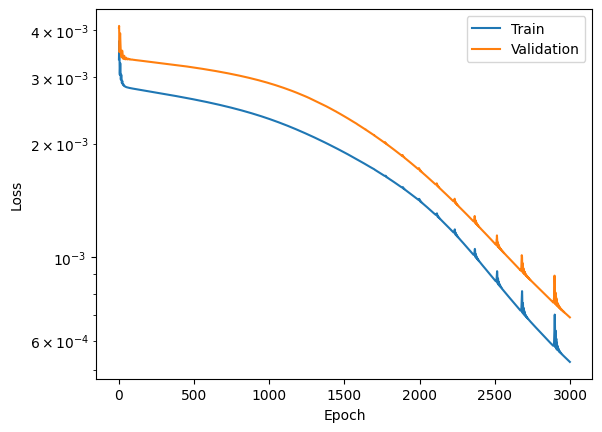

In [ ]:
train_losses = []
val_losses = []

for epoch in range(3000):
    model.train()
    optimizer.zero_grad()
    pred = model(xyz_train)
    loss = criterion(v_train, pred)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_pred = model(xyz_val)
        val_loss = criterion(v_val, val_pred)
    val_losses.append(val_loss.item())
    model.train()

plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Observations:

From 3_D regression:

1. Data requirements grow exponentially with input dimensions
2. Sparse matrices in real industrial data are this problem at scale
3. exp(-z²) is a Gaussian decay — simpler to learn than oscillatory structure
4. Auto-scaling colormaps hide amplitude differences — always fix vmin and vmax when comparing plots
5. Slice plots reveal what a single 3D plot cannot

Generalization vs memorization:

1. Always split data before training — never evaluate on training points
2. Training loss alone tells you nothing about generalization
3. A growing gap between train and val loss means overfitting
4. The best model is at the epoch where validation loss is lowest
5. Early stopping automates finding that point and saves the best weights
6. Gradient clipping prevents large weight updates from destabilizing training

Batching:

1. Mini-batches let you train on data larger than memory
2. More weight updates per epoch = faster convergence
3. GPUs process batches in parallel — 250 small updates aren't 250x slower than 1 large update
4. Stochastic noise in validation loss is normal and expected with mini-batches